In [2]:
import sys
print(sys.executable)
from pathlib import Path
import rasterio
import pandas as pd
import numpy as np

/home/keyuyao/venvs/geo/bin/python


In [17]:

print("PROJ_DATA=", os.environ.get("PROJ_DATA"))
print("PROJ_LIB=", os.environ.get("PROJ_LIB"))


PROJ_DATA= /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Compiler/gcccore/proj/9.4.1/share/proj
PROJ_LIB= /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Compiler/gcccore/proj/9.4.1/share/proj


In [3]:
import os
from pathlib import Path

# Resolve PROJ data dir for pyproj/geopandas on HPC or minimal environments.
def _configure_proj_data_dir():
    candidates = []
    for key in ("PROJ_DATA", "PROJ_LIB"):
        val = os.environ.get(key)
        if val:
            candidates.append(val)

    try:
        import pyproj
        pkg_dir = Path(pyproj.__file__).resolve().parent
        candidates.extend([
            str(pkg_dir / "proj_dir" / "share" / "proj"),
            str(pkg_dir / "data"),
            str(pkg_dir / "proj_data"),
        ])
    except Exception:
        pyproj = None

    candidates.extend([
        "/usr/share/proj",
        "/usr/local/share/proj",
        "/opt/conda/share/proj",
        "/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Compiler/gcccore/proj/9.4.1/share/proj",
    ])

    chosen = next((p for p in candidates if p and (Path(p) / "proj.db").exists()), None)
    if not chosen:
        raise RuntimeError(
            "PROJ data directory not found. Set PROJ_DATA or PROJ_LIB to a folder containing proj.db."
        )

    os.environ["PROJ_DATA"] = chosen
    os.environ["PROJ_LIB"] = chosen

    if 'pyproj' in locals() and pyproj is not None:
        from pyproj import datadir
        datadir.set_data_dir(chosen)

    return chosen

proj_dir = _configure_proj_data_dir()
print(f"Using PROJ data dir: {proj_dir}")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import random
from shapely.geometry import Point, Polygon

/home/keyuyao/venvs/geo/lib/python3.11/site-packages/pyproj/__init__.py:96: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


Using PROJ data dir: /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Compiler/gcccore/proj/9.4.1/share/proj


In [4]:
index_path = "/home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/data/index_geomont_orthophoto2023_monteregie.gpkg"     # or .shp
ortho_folder = "/home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/data/raw"

In [20]:
layers = gpd.list_layers(index_path)
display(layers)

,name,geometry_type
0,index_tuilage,MultiPolygon
1,index_geomont_orthophoto2023,MultiPolygon


In [5]:

# Collect all GeoTIFFs
tif_files = list(Path(ortho_folder).glob("*.tif"))

print(f"Found {len(tif_files)} orthophoto files")

Found 414 orthophoto files


 Extract Metadata Per Orthophoto

In [6]:
records = []

for tif in tif_files:
    with rasterio.open(tif) as src:
        transform = src.transform
        res_x = transform.a
        res_y = -transform.e
        
        bounds = src.bounds
        crs = src.crs
        
        records.append({
            "filename": tif.name,
            "width_px": src.width,
            "height_px": src.height,
            "resolution_x_m": res_x,
            "resolution_y_m": res_y,
            "crs": str(crs),
            "minx": bounds.left,
            "miny": bounds.bottom,
            "maxx": bounds.right,
            "maxy": bounds.top
        })

df = pd.DataFrame(records)
df.head()

,filename,width_px,height_px,resolution_x_m,resolution_y_m,crs,minx,miny,maxx,maxy
0,geomont_orthophoto2023_20cm_2950_390_5055.tif,25000,25000,0.2,0.2,EPSG:2950,390000.0,5050000.0,395000.0,5055000.0
1,geomont_orthophoto2023_20cm_2950_305_5000.tif,25000,25000,0.2,0.2,EPSG:2950,305000.0,4995000.0,310000.0,5000000.0
2,geomont_orthophoto2023_20cm_2950_255_5020.tif,25000,25000,0.2,0.2,EPSG:2950,255000.0,5015000.0,260000.0,5020000.0
3,geomont_orthophoto2023_20cm_2950_330_5085.tif,25000,25000,0.2,0.2,EPSG:2950,330000.0,5080000.0,335000.0,5085000.0
4,geomont_orthophoto2023_20cm_2950_350_5030.tif,25000,25000,0.2,0.2,EPSG:2950,350000.0,5025000.0,355000.0,5030000.0


In [23]:
summary = {
    "number_of_tiles": len(df),
    "mean_resolution_m": df["resolution_x_m"].mean(),
    "unique_crs": df["crs"].unique().tolist(),
    "total_area_km2_estimate": (
        ((df["maxx"] - df["minx"]) * 
         (df["maxy"] - df["miny"])).sum()
    ) / 1e6
}

summary

{'number_of_tiles': 414,
 'mean_resolution_m': 0.19999999999999998,
 'unique_crs': ['EPSG:2950'],
 'total_area_km2_estimate': 10350.0}

Validation: Mostly-Black Tile Check

In [7]:
# Fast black-pixel screening using 9 sampled windows per tile.
# Use this before batching/labeling to exclude unusable imagery.
black_threshold = 10        # pixel considered black if all RGB channels <= this value
flag_ratio_threshold = 0.80 # flag tiles with >=80% sampled black pixels
window_size = 128
sample_fracs = [0.0, 0.5, 1.0]  # corners, edges, center

black_records = []
failed_reads = []

for tif in tif_files:
    try:
        with rasterio.open(tif) as src:
            h, w = src.height, src.width
            black_px = 0
            total_px = 0
            for fy in sample_fracs:
                for fx in sample_fracs:
                    row = int((h - window_size) * fy)
                    col = int((w - window_size) * fx)
                    win = rasterio.windows.Window(col_off=col, row_off=row, width=window_size, height=window_size)
                    arr = src.read(window=win)
                    black_mask = np.all(arr <= black_threshold, axis=0)
                    black_px += int(black_mask.sum())
                    total_px += int(black_mask.size)

        black_records.append({
            "filename": tif.name,
            "black_ratio_sampled": black_px / total_px,
        })
    except Exception as e:
        failed_reads.append({"filename": tif.name, "error": str(e)})

black_df = pd.DataFrame(black_records)
black_df = black_df.sort_values("black_ratio_sampled", ascending=False)

flagged_black = black_df[black_df["black_ratio_sampled"] >= flag_ratio_threshold].copy()
print(f"Flagged tiles (>= {flag_ratio_threshold:.0%} sampled black): {len(flagged_black)}")
display(flagged_black.head(20))
print(f"Unreadable tiles skipped: {len(failed_reads)}")
if failed_reads:
    display(pd.DataFrame(failed_reads).head(20))

# Optional: save blacklist for downstream filtering in labeling workflow.
black_report_path = Path("/home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/data/processed/black_tile_report.csv")
black_df.to_csv(black_report_path, index=False)
if failed_reads:
    failed_report_path = black_report_path.with_name("black_tile_read_errors.csv")
    pd.DataFrame(failed_reads).to_csv(failed_report_path, index=False)
    print(f"Saved read-error report to: {failed_report_path}")
print(f"Saved black-tile report to: {black_report_path}")

Flagged tiles (>= 80% sampled black): 20


,filename,black_ratio_sampled
254,geomont_orthophoto2023_20cm_2950_310_5035.tif,1.000000
166,geomont_orthophoto2023_20cm_2950_300_4985.tif,0.912794
95,geomont_orthophoto2023_20cm_2950_350_5105.tif,0.888889
82,geomont_orthophoto2023_20cm_2950_320_5045.tif,0.888889
63,geomont_orthophoto2023_20cm_2950_375_5040.tif,0.888889
106,geomont_orthophoto2023_20cm_2950_270_5035.tif,0.888889
183,geomont_orthophoto2023_20cm_2950_215_4995.tif,0.888889
329,geomont_orthophoto2023_20cm_2950_265_5040.tif,0.888889
332,geomont_orthophoto2023_20cm_2950_275_5035.tif,0.888889
207,geomont_orthophoto2023_20cm_2950_350_5015.tif,0.888889


Unreadable tiles skipped: 1


,filename,error
0,geomont_orthophoto2023_20cm_2950_350_5090.tif,Read failed. See previous exception for details.


Saved read-error report to: /home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/data/processed/black_tile_read_errors.csv
Saved black-tile report to: /home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/data/processed/black_tile_report.csv


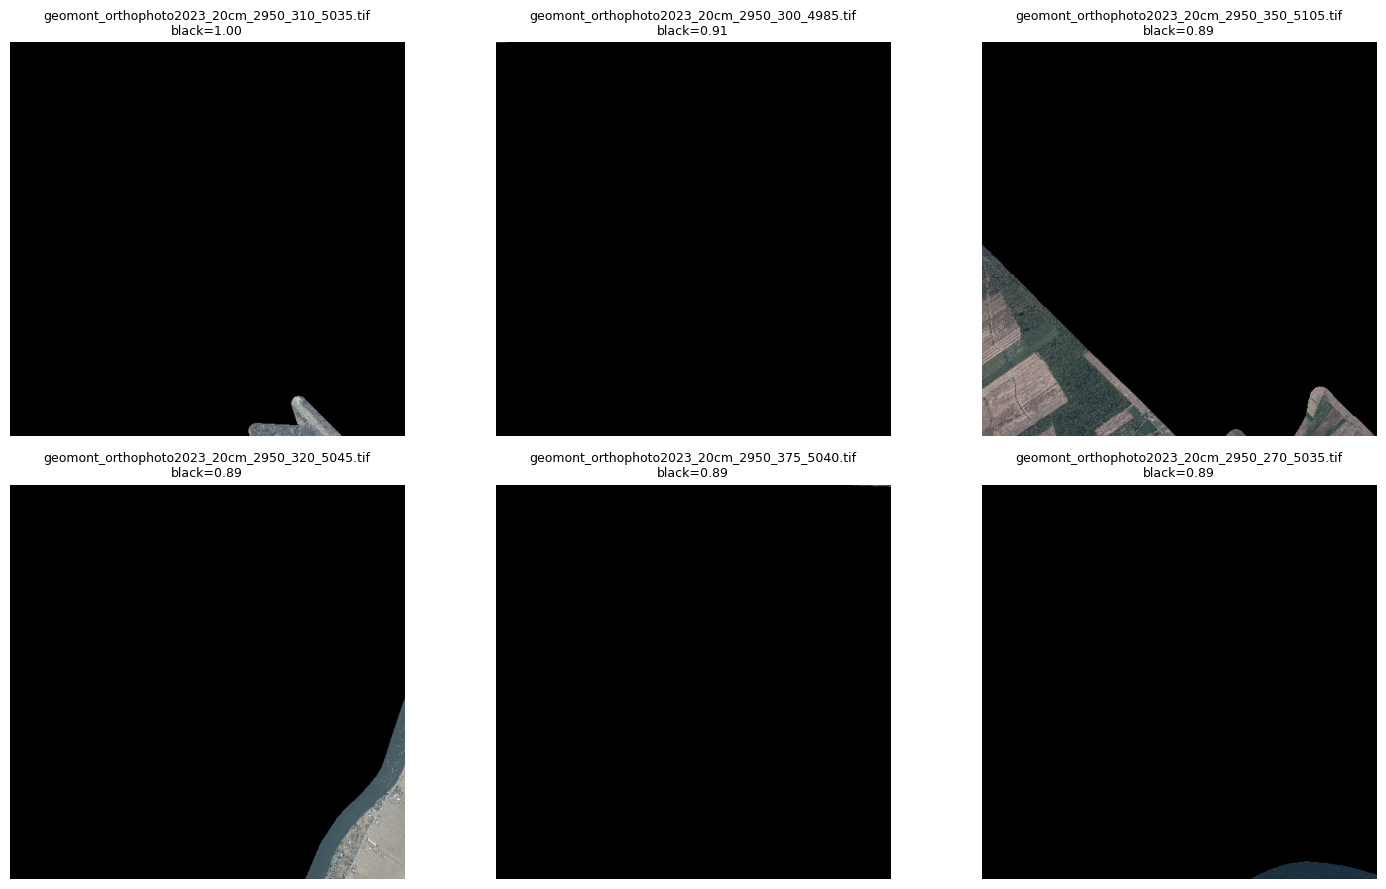

In [8]:
# Visualize flagged black tiles
import sys
local_deps = Path("/home/keyuyao/projects/def-sdaniel/keyuyao/power-grid-detection/.local_deps")
if local_deps.exists() and str(local_deps) not in sys.path:
    sys.path.insert(0, str(local_deps))

import matplotlib.pyplot as plt

n_show = 6
to_show = flagged_black.head(n_show).copy() if len(flagged_black) else black_df.head(n_show).copy()

if to_show.empty:
    print("No tiles available to visualize.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for i, row in enumerate(to_show.itertuples(index=False)):
        tif_path = Path(ortho_folder) / row.filename
        try:
            with rasterio.open(tif_path) as src:
                rgb = src.read([1, 2, 3], out_shape=(3, 512, 512))
            img = np.transpose(rgb, (1, 2, 0))
            axes[i].imshow(img)
            axes[i].set_title(f"{row.filename}\nblack={row.black_ratio_sampled:.2f}", fontsize=9)
            axes[i].axis("off")
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Read failed\\n{row.filename}", ha="center", va="center")
            axes[i].set_title(str(e)[:80], fontsize=8)
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Validation: CRS Consistency + Label Coverage

In [ ]:
# Load index layer and verify CRS alignment with orthophotos
preferred_layer = "index_geomont_orthophoto2023"
layer_name = preferred_layer if preferred_layer in layers["name"].tolist() else layers["name"].iloc[0]

index_gdf = gpd.read_file(index_path, layer=layer_name)
index_crs = str(index_gdf.crs)
tile_crs_values = sorted(df["crs"].dropna().unique().tolist())

print(f"Using index layer: {layer_name}")
print(f"Index CRS: {index_crs}")
print(f"Tile CRS values: {tile_crs_values}")

if len(tile_crs_values) == 1 and tile_crs_values[0] == index_crs:
    print("CRS check: PASS")
else:
    print("CRS check: FAIL (reproject vectors before training data generation)")


Using index layer: index_geomont_orthophoto2023
Index CRS: EPSG:2950
Tile CRS values: ['EPSG:2950']
CRS check: PASS
